### Downloading data from kaggle

In [2]:
!pip install opendatasets legacy-cgi --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/andrewmvd/animal-faces")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: neuralarin
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/animal-faces


100%|██████████| 696M/696M [00:07<00:00, 96.8MB/s]


### Importing Libraries

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import os
from PIL import Image # used to read the images from the directory
import torch
from torch import nn
from torch.optim import Adam
import torchvision.transforms as transforms # used to modify and preprocess all the images
from torch.utils.data import Dataset, DataLoader

In [23]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device available: ", device)

Device available:  cuda


### loading data to dataframe

In [24]:
image_path = []
labels = []

for i in os.listdir("animal-faces/afhq/"):
  for label in os.listdir(f"animal-faces/afhq/{i}"):
    for image in os.listdir(f"animal-faces/afhq/{i}/{label}"):
      labels.append(label)
      image_path.append(f"animal-faces/afhq/{i}/{label}/{image}")

df = pd.DataFrame(zip(image_path, labels), columns = ['image_paths', 'labels'])
df.head()

,image_paths,labels
0,animal-faces/afhq/val/cat/pixabay_cat_000700.jpg,cat
1,animal-faces/afhq/val/cat/pixabay_cat_004434.jpg,cat
2,animal-faces/afhq/val/cat/pixabay_cat_002410.jpg,cat
3,animal-faces/afhq/val/cat/flickr_cat_000350.jpg,cat
4,animal-faces/afhq/val/cat/pixabay_cat_002773.jpg,cat


### Splitting data
*   Training: 70% (of 100% data)
*   Validation: 15% (50% of 30% data)
*   Testing: 15% (50% of 30% data)

In [25]:
# create train_data of 70% of the data
train_data = df.sample(frac=0.7, random_state=7)

# drop training rows to get the remaining 30% for the remaining data
remaining = df.drop(train_data.index)

# split the remaining 30% in half (50%) to get Test and Validation
test_data = remaining.sample(frac=0.5, random_state=7)
validation_data = remaining.drop(test_data.index)

print(f"The original dataset has {len(df)} rows")
print(f"The training dataset has {len(train_data)} rows which is 70% of the data")
print(f"The validation dataset has {len(validation_data)} rows which is 15% of the data")
print(f"The testing dataset has {len(test_data)} rows which is 15% of the data")

The original dataset has 16130 rows
The training dataset has 11291 rows which is 70% of the data
The validation dataset has 2419 rows which is 15% of the data
The testing dataset has 2420 rows which is 15% of the data


### Label encoding

In [26]:
label_encoder = LabelEncoder()
label_encoder.fit(df['labels'])

LabelEncoder()

In [27]:
transform = transforms.Compose([
    transforms.Resize((128, 128)), # one size for all images
    transforms.ToTensor(), # transforms images to pytorch tensors
    transforms.ConvertImageDtype(torch.float) # The values are in floating point numbers
    ]) # transform all images into one clear format (preprocess all images to same properties)

### Custom Dataset Class

In [28]:
class CustomImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
        self.labels = torch.tensor(label_encoder.transform(dataframe['labels']))

    def __len__(self):
        return self.dataframe.shape[0]

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx, 0]
        label = self.labels[idx]

        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label

### Creating Dataset Objects

In [29]:
train_dataset = CustomImageDataset(dataframe=train_data, transform=transform)
test_dataset = CustomImageDataset(dataframe=test_data, transform=transform)
validation_dataset = CustomImageDataset(dataframe=validation_data, transform=transform)

### Visualizing images

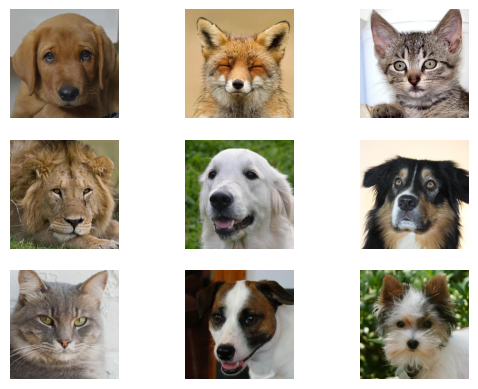

In [30]:
n_rows = 3
n_cols = 3
f, axarr = plt.subplots(n_rows, n_cols)
for row in range(n_rows):
    for col in range(n_cols):
      image = Image.open(df.sample(n = 1)['image_paths'].iloc[0]).convert("RGB")
      axarr[row, col].imshow(image)
      axarr[row, col].axis('off')

plt.show()

In [31]:
learning_rate = 1e-4
batch_size = 16
epochs = 10

In [32]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

# Model Training

In [33]:
class ClassificationModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 128),
            nn.ReLU(),
            nn.Linear(128, len(df['labels'].unique()))
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = ClassificationModel().to(device)

**Model Creation**

In [34]:
from torchsummary import summary
summary(model, input_size = (3, 128, 128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
              ReLU-2         [-1, 32, 128, 128]               0
         MaxPool2d-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
              ReLU-5           [-1, 64, 64, 64]               0
         MaxPool2d-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
              ReLU-8          [-1, 128, 32, 32]               0
         MaxPool2d-9          [-1, 128, 16, 16]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                  [-1, 128]       4,194,432
             ReLU-12                  [-1, 128]               0
           Linear-13                    [-1, 3]             387
Total params: 4,288,067
Trainable param

In [35]:
# define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=learning_rate)

In [36]:
# Early stopping settings
patience = 2  # stop if validation loss does not improve for 2 consecutive epochs
best_val_loss = float("inf")
patience_counter = 0
best_model_state = None

### Training Loop

In [37]:
total_training_loss = []
total_validation_loss = []
total_training_accuracy = []
total_validation_accuracy = []

for epoch in range(epochs):

    total_train_loss = 0
    total_train_accuracy = 0
    total_val_loss = 0
    total_val_accuracy = 0

    # Training
    model.train()

    for inputs, labels in train_loader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        prediction = model(inputs)

        loss = criterion(prediction, labels)

        total_train_loss += loss.item()

        accuracy = (torch.argmax(prediction, dim=1) == labels).sum().item()
        total_train_accuracy += accuracy

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Validation
    model.eval()

    with torch.no_grad():

        for inputs, labels in validation_loader:

            inputs = inputs.to(device)
            labels = labels.to(device)

            prediction = model(inputs)

            loss = criterion(prediction, labels)

            total_val_loss += loss.item()

            accuracy = (torch.argmax(prediction, dim=1) == labels).sum().item()
            total_val_accuracy += accuracy

    # Average metrics
    train_loss = total_train_loss / len(train_loader)
    val_loss = total_val_loss / len(validation_loader)

    train_accuracy = total_train_accuracy / len(train_dataset) * 100
    val_accuracy = total_val_accuracy / len(validation_dataset) * 100

    # Store metrics
    total_training_loss.append(train_loss)
    total_validation_loss.append(val_loss)
    total_training_accuracy.append(train_accuracy)
    total_validation_accuracy.append(val_accuracy)

    print(f"| Epoch: {epoch + 1} | Train Accuracy: {train_accuracy:.2f}% | Train Loss: {train_loss:.4f} | Validation Accuracy: {val_accuracy:.2f}% | Validation Loss: {val_loss:.4f} |")
    print("-" * 114)


    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = model.state_dict().copy()
    else:
        patience_counter += 1

        if patience_counter >= patience:
            print("🛑 Early stopping triggered.")
            model.load_state_dict(best_model_state)
            break

| Epoch: 1 | Train Accuracy: 68.76% | Train Loss: 0.6910 | Validation Accuracy: 77.64% | Validation Loss: 0.5116 |
------------------------------------------------------------------------------------------------------------------
| Epoch: 2 | Train Accuracy: 87.36% | Train Loss: 0.3365 | Validation Accuracy: 85.70% | Validation Loss: 0.3747 |
------------------------------------------------------------------------------------------------------------------
| Epoch: 3 | Train Accuracy: 91.13% | Train Loss: 0.2439 | Validation Accuracy: 91.28% | Validation Loss: 0.2344 |
------------------------------------------------------------------------------------------------------------------
| Epoch: 4 | Train Accuracy: 92.68% | Train Loss: 0.2013 | Validation Accuracy: 92.39% | Validation Loss: 0.2022 |
------------------------------------------------------------------------------------------------------------------
| Epoch: 5 | Train Accuracy: 94.07% | Train Loss: 0.1630 | Validation Accuracy: 

### Model Testing

In [38]:
model.eval()

total_test_loss = 0
total_test_accuracy = 0

with torch.no_grad():

    for inputs, labels in test_loader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        prediction = model(inputs)

        loss = criterion(prediction, labels)
        total_test_loss += loss.item()

        predicted = torch.argmax(prediction, dim=1)
        correct = (predicted == labels).sum().item()
        total_test_accuracy += correct

test_loss = total_test_loss / len(test_loader)
test_accuracy = total_test_accuracy / len(test_loader.dataset) * 100

print("-" * 45)
print(f"| Test Accuracy: {test_accuracy:.2f}% | Test Loss: {test_loss:.4f} |")
print("-" * 45)

---------------------------------------------
| Test Accuracy: 95.50% | Test Loss: 0.1354 |
---------------------------------------------


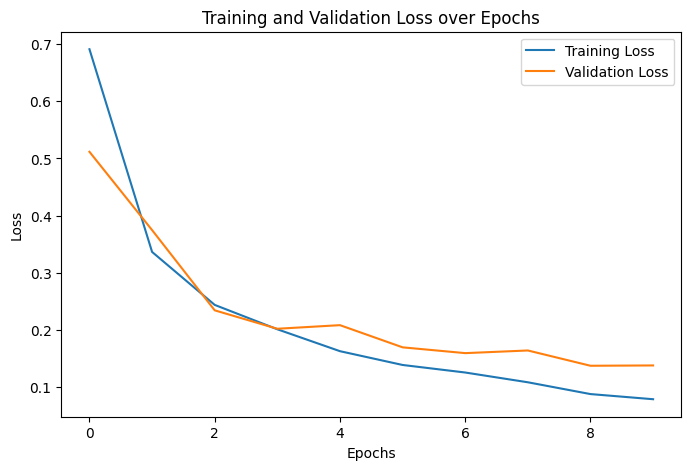

In [39]:
plt.figure(figsize=(8, 5))

plt.plot(total_training_loss, label='Training Loss')
plt.plot(total_validation_loss, label='Validation Loss')

plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

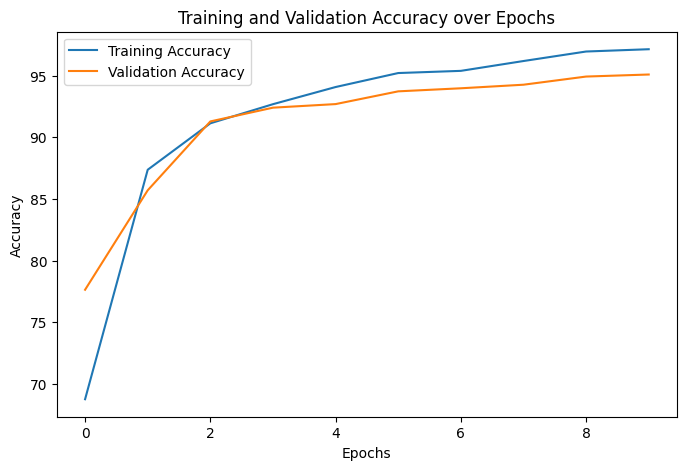

In [40]:
plt.figure(figsize=(8, 5))
plt.plot(total_training_accuracy, label='Training Accuracy')
plt.plot(total_validation_accuracy, label='Validation Accuracy')
plt.title('Training and Validation Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

**Model Testing**

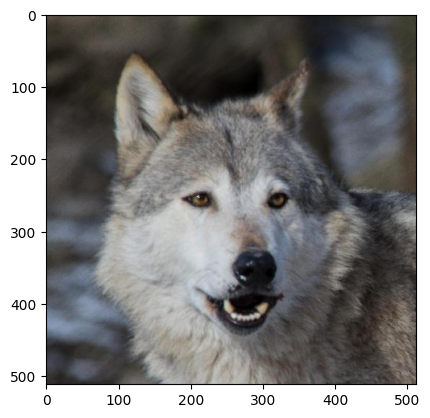


Prediction: 

['wild']


In [41]:
def predict_image(image_path):
  image = Image.open(image_path).convert('RGB')
  image = transform(image).to(device)

  output = model(image.unsqueeze(0))
  output = torch.argmax(output, axis = 1).item()
  return label_encoder.inverse_transform([output])

## Get a sample image from the dataset
sample_image_path = df.sample(n=1)['image_paths'].iloc[0]

## Visualize the image
image = Image.open(sample_image_path)
plt.imshow(image)
plt.show()


## Predict
print()
print("Prediction: \n")
prediction = predict_image(sample_image_path)
print(prediction)

In [42]:
# Save the model for deployment
torch.save(model.state_dict(), 'animal_classifier.pth')
print("Model successfully saved to 'animal_classifier.pth'!")

Model successfully saved to 'animal_classifier.pth'!
